<div style="background-color:#EFF5FF; padding:22px; border-radius:10px; border-left:8px solid #0047AB;">

<h1 style="margin-bottom:0;"><b>Machine Learning II</b></h1>
<h3><b>Customer Segmentation — Exploratory Data Analysis and Preprocessing</b></h3>

<p style="font-size:15px; margin-top:14px;">
This notebook prepares the <code>customer_info</code> dataset for the clustering stage. The goal is to clean the data, engineer meaningful customer features, protect identifiers from distance-based transformations, handle missing values safely, and export a clean dataset that can be used for segmentation models.
</p>

</div>


<div style="background-color:#EFF5FF; padding:18px; border-radius:10px; border-left:8px solid #0047AB;">

<h2 style="margin-top:0;"><b>Notebook Index</b></h2>

<p>This index follows the full workflow from raw data inspection to the final clustering-ready export.</p>

<ol>
  <li><a href="#section-1-imports-and-data-loading">Imports and Data Loading</a></li>
  <li><a href="#section-1-1-data-analysis">Initial Data Analysis</a></li>
  <li><a href="#section-1-2-duplicate-rows-analysis">Duplicate Rows Analysis</a></li>
  <li><a href="#section-1-3-missing-values-analysis">Missing Values Analysis</a></li>
  <li><a href="#section-1-4-numerical-and-categorical-columns">Numerical and Categorical Columns</a></li>
  <li><a href="#section-1-5-statistical-summary">Statistical Summary</a></li>
  <li><a href="#section-2-data-cleaning">Data Cleaning</a></li>
  <li><a href="#section-2-1-invalid-future-years">Invalid Future Years</a></li>
  <li><a href="#section-2-2-negative-values">Negative Values</a></li>
  <li><a href="#section-2-3-negative-percentages">Negative Percentages</a></li>
  <li><a href="#section-2-4-data-types">Data Type Fixes</a></li>
  <li><a href="#section-2-5-missing-values-treatment">Missing Values Treatment</a></li>
  <li><a href="#section-3-aggregation-feature-engineering">Aggregation Feature Engineering</a></li>
  <li><a href="#section-4-missing-values-imputation">KNN Missing Values Imputation</a></li>
  <li><a href="#section-5-transformation-feature-engineering">Transformation Feature Engineering</a></li>
  <li><a href="#section-6-outliers-treatment">Outliers Treatment</a></li>
  <li><a href="#section-7-multivariate-analysis">Multivariate Analysis</a></li>
  <li><a href="#section-8-feature-selection-and-export">Feature Selection and Final Export</a></li>
</ol>

</div>


<a id="section-1-imports-and-data-loading"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>1. Imports and Data Loading</b></h3>
</div>


In [69]:
%load_ext autoreload
%autoreload 2

import os
import sys
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure the current directory is available for importing utils_eda.py
sys.path.append(os.path.abspath('.'))

warnings.filterwarnings("ignore")

import utils_eda as utils

# Plot style settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<div style="background-color:#F9FCFF; padding:20px; border-radius:10px;">

We start by loading the core libraries and the project utility module. The autoreload setup is useful during development because changes made in <code>utils_eda.py</code> are picked up automatically without restarting the kernel.

</div>


<a id="section-1-1-data-analysis"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>1.1 Initial Data Analysis</b></h3>
</div>


<div style="background-color:#F9FCFF; padding:20px; border-radius:10px;">

After loading the dataset, we inspect its shape, column types, and sample records. This gives us a quick sense of what needs to be cleaned before we start creating features for clustering.

</div>


In [70]:
DATA_PATH = "../datasets/customer_info.csv"
ci = pd.read_csv(DATA_PATH)

In [71]:
pd.set_option('display.max_columns', None)
ci.sort_index(inplace = True)
display(ci.head())

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,NaN,373.0,323.0,177.0,28.0,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
1,4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,NaN,2012.0,533.0,95.0,43.0,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
2,5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,11.0,555.0,101.0,118.0,1265.0,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
3,7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,84.0,757.0,1133.0,972.0,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
4,8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,380.0,592.0,718.0,1068.0,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188


In [72]:
display(ci.tail())

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
33033,39996,Joshua Howard,male,05/16/1973 02:04 PM,0.0,0.0,2.0,1.0,475.0,13488.0,NaN,190.0,573.0,994.0,1020.0,1154.0,62.0,1598.0,366.0,162.0,0.261352,2014.0,NaN,38.742306,-9.163971
33034,39997,Anthony Hines,male,05/10/1955 01:19 AM,1.0,0.0,1.0,1.0,8430.0,14408.0,21.0,291.0,497.0,1417.0,1323.0,602.0,220.0,2105.0,227.0,97.0,0.143479,2014.0,NaN,38.748505,-9.193445
33035,39998,Edna Hasselman,female,05/15/1945 11:09 PM,1.0,1.0,0.0,4.0,8029.0,1480.0,14.0,1600.0,494.0,117.0,307.0,NaN,1719.0,89.0,258.0,206.0,0.181917,2012.0,NaN,38.776003,-9.137943
33036,39999,George Kramer,male,05/25/1951 09:02 PM,1.0,1.0,1.0,6.0,8364.0,3114.0,11.0,596.0,303.0,661.0,NaN,113.0,410.0,NaN,225.0,385.0,0.807259,2017.0,NaN,38.736034,-9.145235
33037,40000,Sammie Wright,female,07/09/1990 10:27 AM,0.0,1.0,1.0,1.0,4774.0,2127.0,7.0,701.0,387.0,126.0,816.0,729.0,1331.0,323.0,239.0,102.0,0.252563,2017.0,NaN,38.758936,-9.145988


<div style="background-color:#F9FCFF; padding:20px; border-radius:10px;">
We use the `.info()` method to verify the column names, non-null counts, and data types. This allows us to identify columns that require type conversion (e.g., dates or numerical counts stored as floats) and gives us an initial glimpse of the data density.

In [73]:
display(ci.info(memory_usage="deep"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33038 entries, 0 to 33037
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_id                              33038 non-null  int64  
 1   customer_name                            33038 non-null  object 
 2   customer_gender                          33038 non-null  object 
 3   customer_birthdate                       32873 non-null  object 
 4   kids_home                                32708 non-null  float64
 5   teens_home                               32708 non-null  float64
 6   number_complaints                        32377 non-null  float64
 7   distinct_stores_visited                  32708 non-null  float64
 8   lifetime_spend_groceries                 33038 non-null  float64
 9   lifetime_spend_electronics               32377 non-null  float64
 10  typical_hour                             32377

None

<a id="section-1-2-duplicate-rows-analysis"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>1.2 Duplicate Rows Analysis</b></h3>
</div>


<div style="background-color:#F9FCFF; padding:20px; border-radius:10px;">
To ensure the reliability of our clusters, we check for duplicate records. Duplicate rows can artificially inflate the importance of certain customer profiles and lead to biased segmentation results.

In [74]:
duplicate_rows = ci[ci.duplicated()]
display(duplicate_rows.head())

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude


<div style="background-color:#F9FCFF; padding:20px; border-radius:10px;">
While checking for exact row duplicates is standard, it is also important to perform a more granular search for "logical duplicates". 

In this step, we specifically look for records that share the same **Customer Name** and **Birthdate**. Identifying such cases is vital because:
* **Data Overlap:** The same individual might have been registered twice under different IDs.
* **Clustering Bias:** If the same customer profile appears multiple times, it will unfairly pull a cluster center toward its specific attributes, distorting the final segmentation.

In [75]:
ci[ci[['customer_name', 'customer_birthdate']].duplicated()]

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude


<a id="section-1-3-missing-values-analysis"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>1.3 Missing Values Analysis</b></h3>
</div>


<div style="background-color:#F9FCFF; padding:20px; border-radius:10px;">
    
Missing data is a common challenge in customer datasets. We generate a missing value report to:
* Quantify the percentage of missing information per feature.
* Visualize the missing data using a barplot.
* Determine which variables require **KNN Imputation** and which ones might be too empty to be useful.

In [76]:
missing_df = utils.get_missing_percent(ci)

In [77]:
display(missing_df.sort_values("Missing_Percent", ascending=False).head(15))

,Column,Missing_Percent
22,loyalty_card_number,39.67
15,lifetime_spend_fish,3.00
17,lifetime_spend_videogames,2.00
10,typical_hour,2.00
14,lifetime_spend_meat,2.00
9,lifetime_spend_electronics,2.00
11,lifetime_spend_vegetables,2.00
18,lifetime_spend_petfood,2.00
6,number_complaints,2.00
13,lifetime_spend_alcohol_drinks,1.00


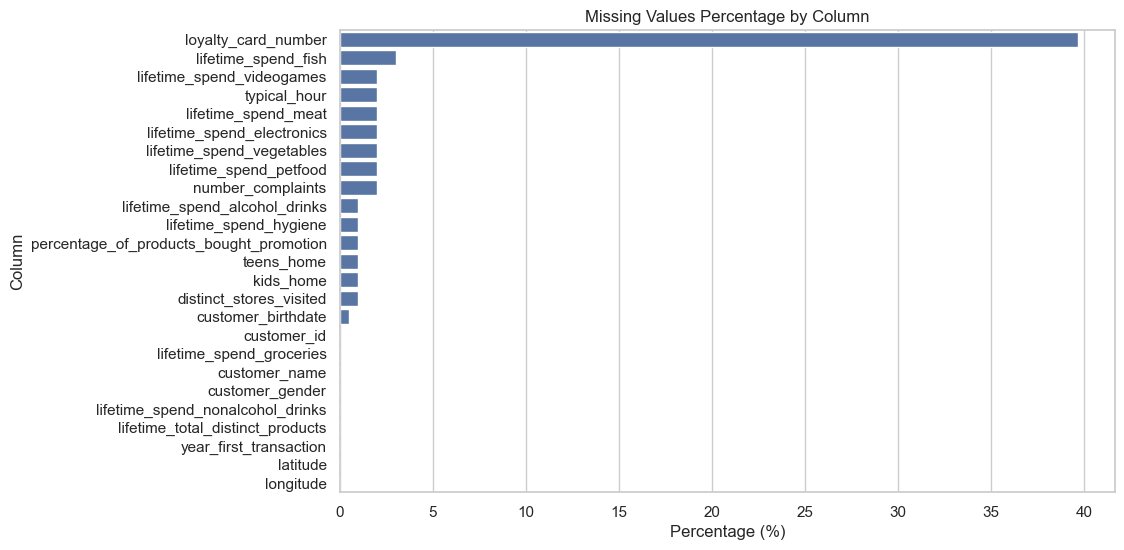

In [78]:
plt.figure(figsize=(10,6))
sns.barplot(x='Missing_Percent', y='Column', data=missing_df)
plt.title("Missing Values Percentage by Column")
plt.xlabel("Percentage (%)")
plt.ylabel("Column")
plt.show()

<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">

We identify features with a missing value percentage higher than **30%**. This threshold is critical because:
* **Information Loss:** Variables with high sparsity often lack enough signal to be reliably imputed.
* **Model Integrity:** Including features with excessive missing data can introduce significant noise into the clustering process, potentially leading to distorted segments.


In [79]:
high_missing = missing_df[missing_df['Missing_Percent'] > 30]
display(high_missing)

,Column,Missing_Percent
22,loyalty_card_number,39.67


<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">
We evaluate the number of unique values in the `loyalty_card_number` column to determine its nature.

In [80]:
print(f"Unique Values of column loyalty_card_number: {ci['loyalty_card_number'].nunique()}")

Unique Values of column loyalty_card_number: 1


<a id="section-1-4-numerical-and-categorical-columns"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>1.4 Numerical and Categorical Columns</b></h3>
</div>


In [81]:
numerical_cols = ci.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = ci.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}):")
display(pd.DataFrame(numerical_cols, columns=['Numerical Columns']))

print(f"Categorical columns ({len(categorical_cols)}):")
display(pd.DataFrame(categorical_cols, columns=['Categorical Columns']))

Numerical columns (22):


,Numerical Columns
0,customer_id
1,kids_home
2,teens_home
3,number_complaints
4,distinct_stores_visited
5,lifetime_spend_groceries
6,lifetime_spend_electronics
7,typical_hour
8,lifetime_spend_vegetables
9,lifetime_spend_nonalcohol_drinks


Categorical columns (3):


,Categorical Columns
0,customer_name
1,customer_gender
2,customer_birthdate


<div style="background-color:#F7FBFF; padding:15px; border-radius:10px; ">

To properly prepare our preprocessing pipeline, we categorize the variables into Numerical and Categorical types. This distinction is essential as each group requires specific cleaning and transformation strategies.

Numerical Features (21 Variables)
These columns represent quantitative data, including spending amounts, household counts, and geographic coordinates.
* **Household & Behavior:** `kids_home`, `teens_home`, `number_complaints`, `distinct_stores_visited`.
* **Spending Habits:** `lifetime_spend_` (Groceries, Electronics, Vegetables, Non-alcoholic, Alcohol, Meat, Fish, Hygiene, Videogames, Petfood).
* **Metrics & Time:** `lifetime_total_distinct_products`, `percentage_of_products_bought_promotion`, `typical_hour`, `year_first_transaction`.
* **Geospatial & IDs:** `latitude`, `longitude`, `loyalty_card_number`.

Categorical Features (3 Variables)
These columns contain qualitative information or timestamps that define the customer profile.
* **Demographics:** `customer_gender`.
* **Identification:** `customer_name`.
* **Temporal:** `customer_birthdate` (to be used for age calculation).

</div>

<a id="section-1-4-1-categorical-columns"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>1.4.1 Findings in Categorical Columns</b></h3>
</div>


In [82]:
ci[["customer_name"]]

,customer_name
0,Bsc. Crystal Kitchens
1,Bsc. Glenda Bauman
2,Msc. Antonio Campbell
3,John Kelling
4,Arthur Dematteo
...,...
33033,Joshua Howard
33034,Anthony Hines
33035,Edna Hasselman
33036,George Kramer


<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">

A detailed inspection of the `customer_name` field reveals that it contains more than just identification data. Many entries include academic prefixes such as **Bsc.**, **Msc.**, and **Phd.**

* **Observation:** The dataset contains 33,038 unique customer names.
* **Feature Engineering Opportunity:** These prefixes are a proxy for the customer's **Education Level**. Instead of treating names as simple strings, we can extract these titles to create an ordinal numerical feature (e.g., 1 for Bsc, 2 for Msc, 3 for Phd).
* **Data Cleaning:** Once the education level is extracted, the names can be cleaned of these prefixes to standardize the field, although the names themselves will eventually be excluded from the clustering model to protect privacy and focus on behavioral patterns.

</div>

<a id="section-1-5-statistical-summary"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>1.5 Statistical Summary</b></h3>
</div>


<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">
    
We perform a statistical summary of the numerical features using the `.describe()` method. This allows us to observe the central tendency, dispersion, and range of our variables, providing critical insights into the data's distribution.


In [83]:
print("Statistical summary for numerical columns:")
ci[numerical_cols].describe().T

Statistical summary for numerical columns:


,count,mean,std,min,25%,50%,75%,max
customer_id,33038.0,19974.265785,11538.538632,3.000000,9985.250000,19951.500000,29964.750000,40000.000000
kids_home,32708.0,1.116118,1.150186,0.000000,0.000000,1.000000,1.000000,8.000000
teens_home,32708.0,0.898893,0.962924,0.000000,0.000000,1.000000,1.000000,6.000000
number_complaints,32377.0,0.930846,0.894658,0.000000,0.000000,1.000000,1.000000,7.000000
distinct_stores_visited,32708.0,3.167941,1.674114,1.000000,2.000000,3.000000,4.000000,10.000000
lifetime_spend_groceries,33038.0,16306.227798,11985.903518,0.000000,8647.000000,13002.500000,20807.000000,104670.000000
lifetime_spend_electronics,32377.0,2763.080088,3453.191495,0.000000,579.000000,1470.000000,3745.000000,35299.000000
typical_hour,32377.0,12.659388,4.854708,6.000000,8.000000,12.000000,16.000000,23.000000
lifetime_spend_vegetables,32377.0,727.223801,654.633087,0.000000,224.000000,471.000000,1074.000000,3337.000000
lifetime_spend_nonalcohol_drinks,33038.0,464.352776,275.767976,0.000000,241.000000,421.000000,640.000000,2180.000000


<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">

Based on the summary table, we can identify several areas that require attention during the pre-processing phase:

* **Constant Features:** The `loyalty_card_number` has a standard deviation of **0.0**, confirming it is a constant value across the dataset and provides no predictive power for clustering.
* **Data Entry Errors:** **Negative Values:** The `percentage_of_products_bought_promotion` shows a minimum value of **-1.27**, which is physically impossible for a percentage.
    * **Future Dates:** The `year_first_transaction` has a maximum value of **2029**, indicating erroneous entries that exceed the current year.
* **Spending Variance:** Columns like `lifetime_spend_groceries` and `lifetime_spend_electronics` exhibit very high standard deviations relative to their means. This suggests a high degree of heterogeneity in customer behavior, which is ideal for segmentation but also indicates the presence of **extreme outliers** that must be capped.
* **Missing Data Clues:** The varying "count" values (ranging from ~20k to 33k) confirm that several features have significant gaps that will be addressed via **KNN Imputation**.

</div>

In [84]:
condition = (ci['percentage_of_products_bought_promotion'] < 0.0) | (ci['percentage_of_products_bought_promotion'] > 1.0)
rows_wrong = ci[condition]
display(rows_wrong.head())

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
8,12,Phd. Dorothy Pacheco,female,05/19/2000 03:02 AM,0.0,0.0,0.0,2.0,9281.0,254.0,18.0,125.0,60.0,1549.0,139.0,598.0,673.0,71.0,64.0,29.0,-0.131176,2018.0,NaN,38.748616,-9.167756
26,35,Bsc. Thomas King,male,08/08/1979 05:25 AM,NaN,1.0,0.0,2.0,37795.0,2130.0,8.0,636.0,102.0,310.0,890.0,844.0,842.0,42.0,524.0,212.0,-0.025524,2011.0,1.0,38.762036,-9.158847
28,37,Phd. Alonzo Crossan,male,09/29/2000 07:54 PM,1.0,1.0,0.0,5.0,25539.0,1089.0,7.0,907.0,1681.0,896.0,1153.0,962.0,1205.0,344.0,329.0,330.0,-0.184820,2028.0,1.0,38.729700,-9.196585
65,81,Phd. Denise Allard,female,03/18/1992 06:34 PM,2.0,0.0,2.0,1.0,6273.0,430.0,6.0,208.0,291.0,525.0,539.0,804.0,707.0,121.0,320.0,91.0,-0.217805,2020.0,1.0,38.748092,-9.155615
71,87,Phd. Milagro Amelung,female,09/03/1977 11:26 AM,1.0,1.0,1.0,3.0,28825.0,2948.0,15.0,459.0,687.0,716.0,884.0,1495.0,1314.0,161.0,916.0,337.0,-0.022180,2008.0,1.0,38.776791,-9.146792


<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">

We perform a targeted integrity check on the `percentage_of_products_bought_promotion` feature. Since this variable represents a ratio, any value outside the range of **[0, 1]** is considered a data entry error.

* **Condition defined:** We filter for values strictly less than 0.0 or greater than 1.0.
* **Findings:** As noted in the descriptive statistics, there are records with negative values (e.g., -1.27), which are physically impossible.
* **Objective:** Identifying these specific rows allows us to treat them as "missing data" (NaN), ensuring they are later corrected by our **KNN Imputation** strategy rather than biasing our analysis with impossible values.

</div>

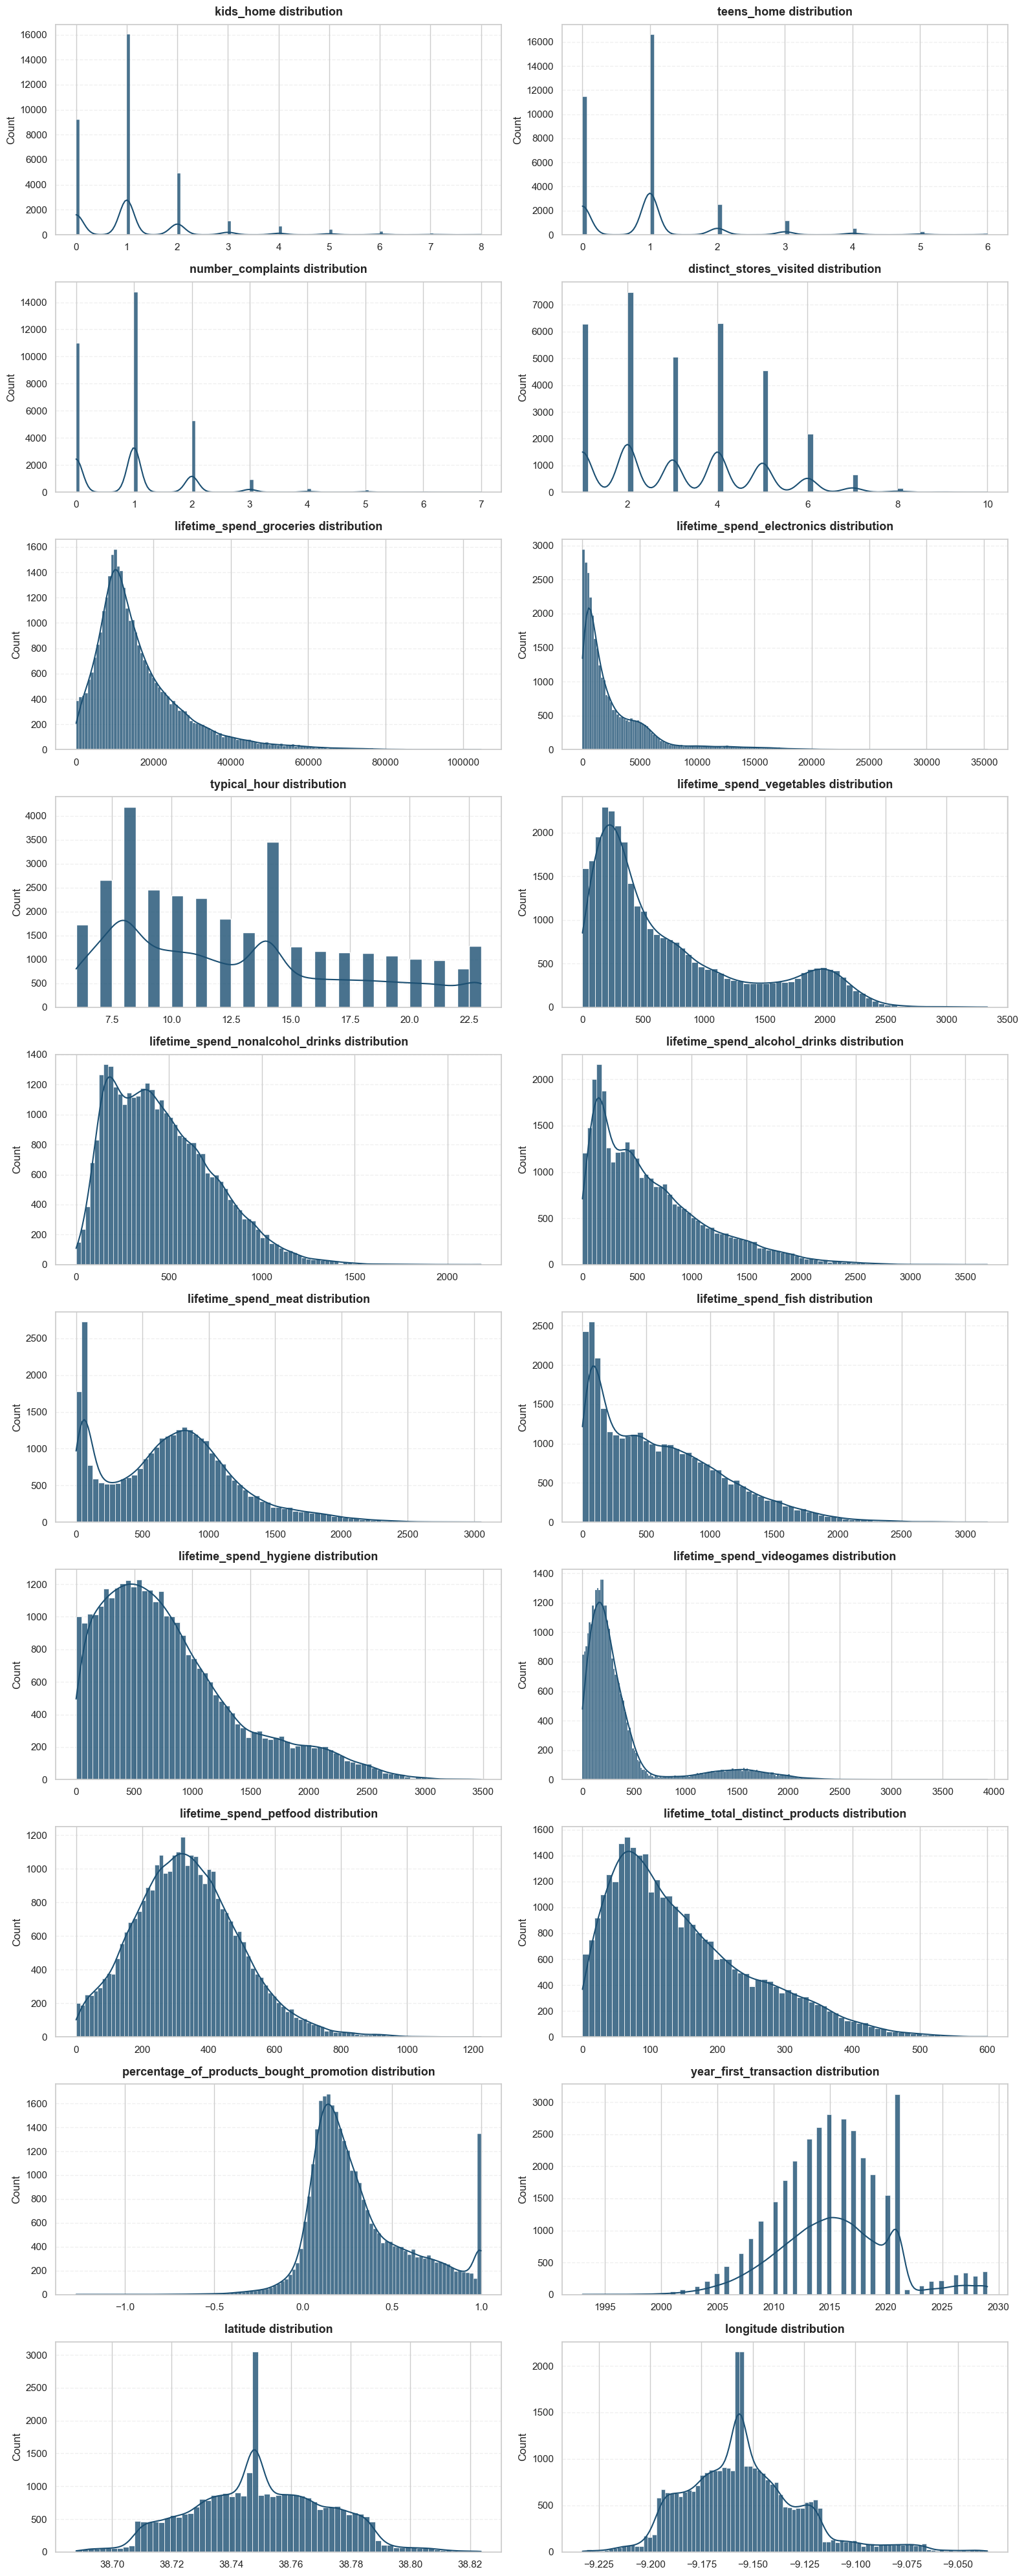

In [85]:
CUSTOM_BLUE = "#1B4F72"

vars_to_plot = list(ci.select_dtypes(include=np.number).columns)
for col in ['loyalty_card_number', 'customer_id', 'customer_loyalty_flag']:
    if col in vars_to_plot: vars_to_plot.remove(col)

fig, axes = plt.subplots(nrows=(len(vars_to_plot) + 1) // 2, ncols=2, figsize=(16, len(vars_to_plot) * 2))
axes = axes.flatten()

for i, col in enumerate(vars_to_plot):
    sns.histplot(ci[col], kde=True, ax=axes[i], color=CUSTOM_BLUE, alpha=0.8)
    axes[i].set_title(f'{col} distribution', fontsize=13, fontweight='bold', pad=10)
    axes[i].set_xlabel('')
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">

The histograms allow us to understand the "shape" of our customer base.

#### **Spending Categories**
* **Skewness:** Most spending features (Electronics, Alcohol, Meat) are **right-skewed**. A large portion of customers spends small amounts, while a "long tail" of high-spenders exists.
* **Outliers:** The boxplots confirm significant outliers in `lifetime_spend_electronics` and `lifetime_spend_groceries`. This reinforces the need for the **IQR Capping** strategy we implemented to prevent these extreme cases from dominating the cluster definitions.

#### **Temporal & Behavioral Patterns**
* **Typical Hour:** The distribution shows peaks during specific times of the day. We wil use the **Sine/Cosine transformation**to preserve the proximity between the late-night and early-morning peaks.
* **Promotion Sensitivity:** The distribution of `percentage_of_products_bought_promotion` shows that while most customers are moderately sensitive to deals, there is a distinct group of "deal hunters" who buy almost exclusively on promotion.

</div>

In [86]:
# Skewness analysis

skewness_df = pd.DataFrame({
    "feature": vars_to_plot,
    "skewness": [ci[col].skew() for col in vars_to_plot]
})

display(
    skewness_df.sort_values(
        by="skewness",
        key=abs,
        ascending=False
    )
)

,feature,skewness
5,lifetime_spend_electronics,2.533751
13,lifetime_spend_videogames,2.427626
0,kids_home,2.123606
1,teens_home,1.898104
4,lifetime_spend_groceries,1.808936
2,number_complaints,1.344178
9,lifetime_spend_alcohol_drinks,1.199248
12,lifetime_spend_hygiene,1.035438
7,lifetime_spend_vegetables,1.035036
15,lifetime_total_distinct_products,0.947159


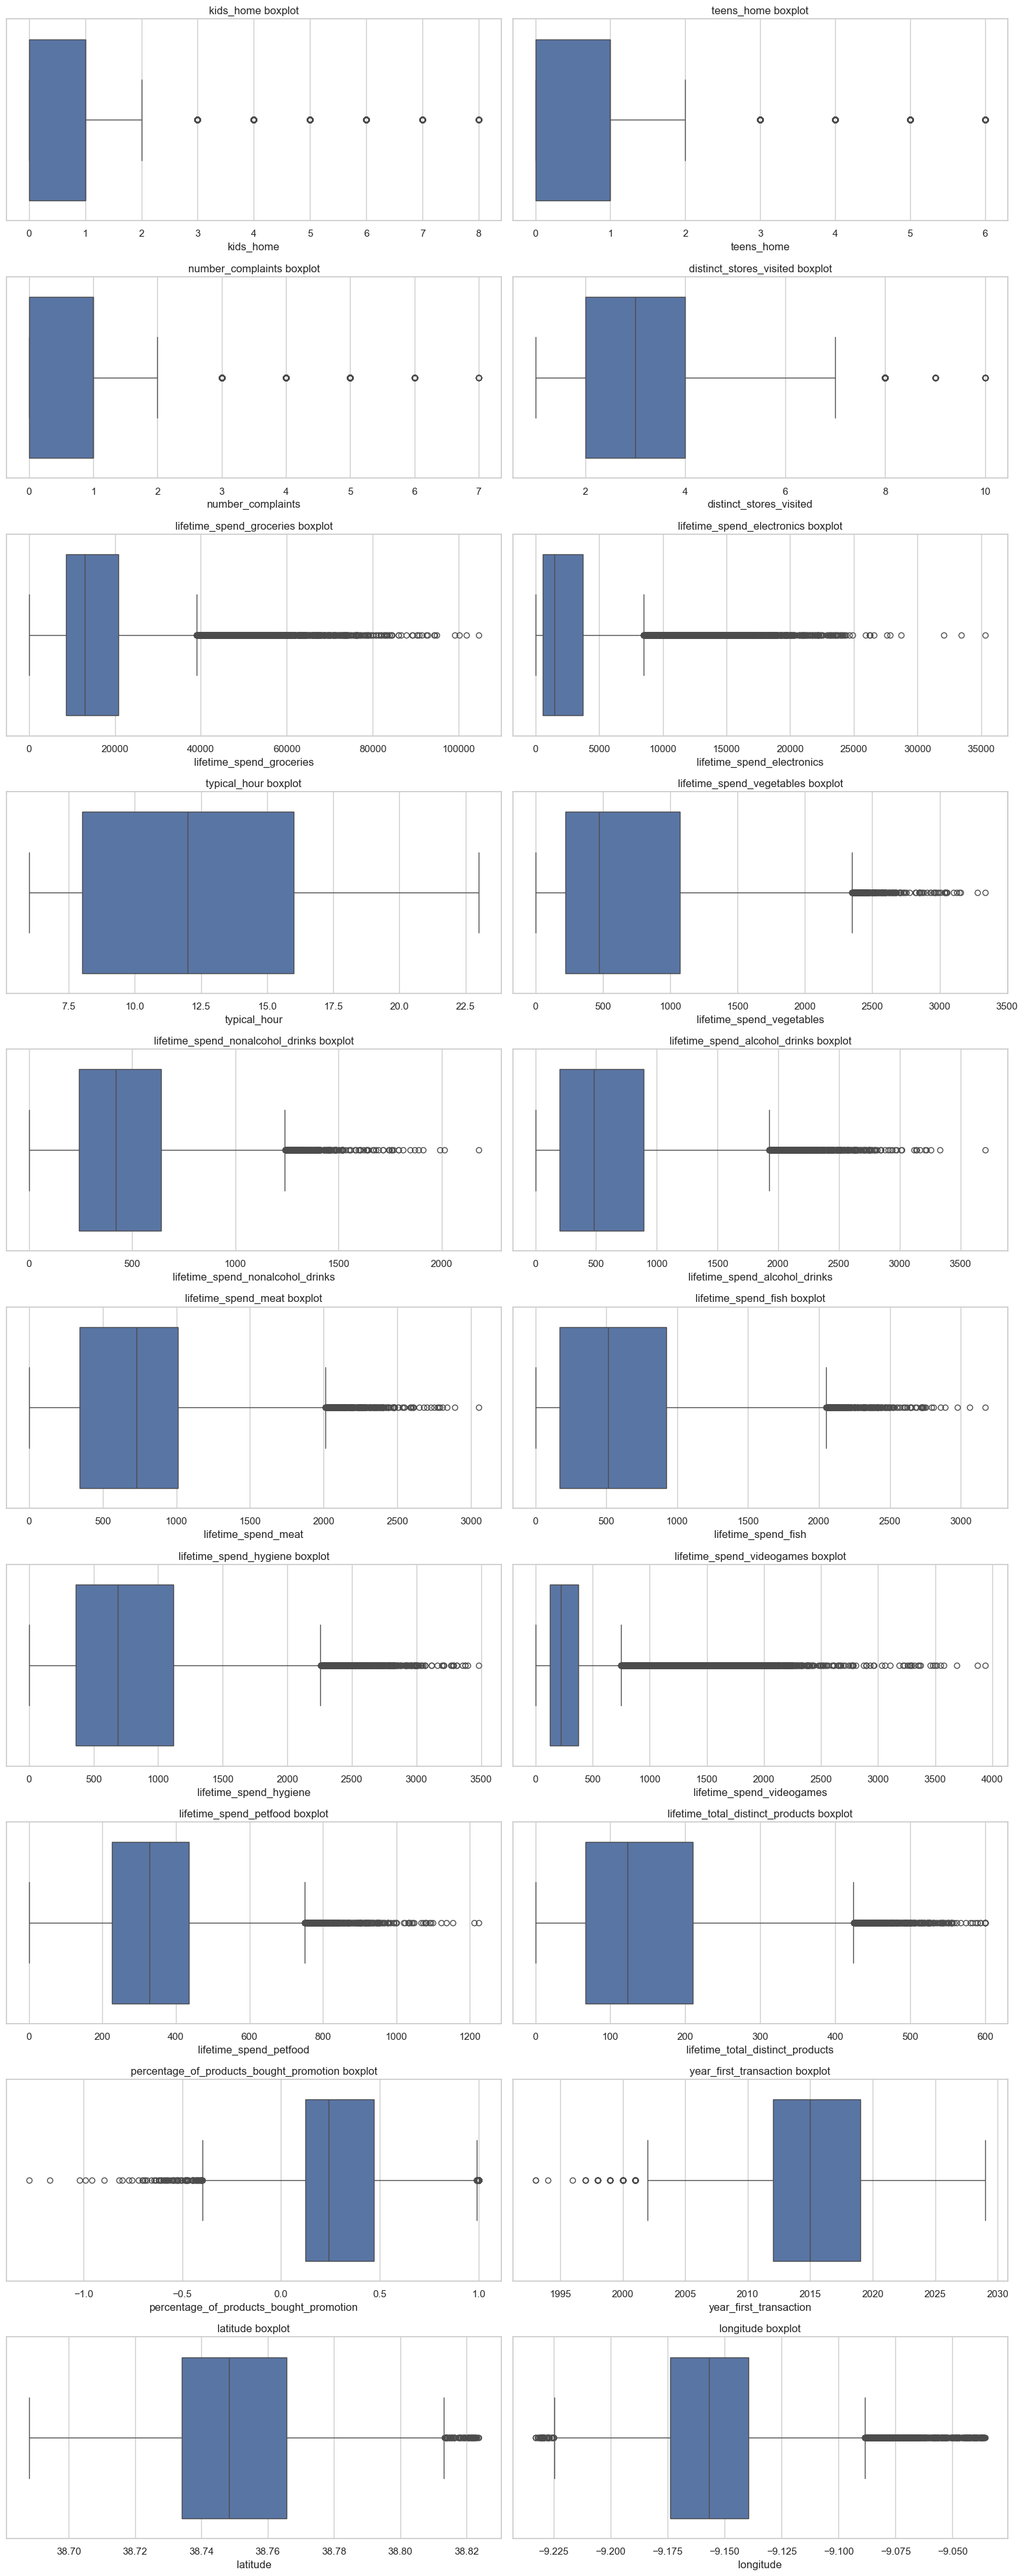

In [87]:
# Boxplots for outlier inspection

fig, axes = plt.subplots(
    nrows=(len(vars_to_plot) + 1) // 2,
    ncols=2,
    figsize=(16, len(vars_to_plot) * 2)
)

axes = axes.flatten()

for i, col in enumerate(vars_to_plot):
    
    sns.boxplot(
        x=ci[col],
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col} boxplot")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

<a id="section-2-data-cleaning"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>2. Data Cleaning</b></h3>
</div>


In [88]:
ci_clean = ci.copy()
print("Initial shape:", ci_clean.shape)

Initial shape: (33038, 25)


<a id="section-2-1-invalid-future-years"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>2.1 Detecting Invalid Future Years</b></h3>
</div>


<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">

To convert static dates into dynamic behavioral features, we first establish the current temporal baseline.

* **Objective:** Capture the current year using `pd.Timestamp.now().year`.
* **Application:** This value serves as the reference point for calculating:
    * **Customer Age:** Derived from `customer_birthdate`.
    * **Customer Tenure:** Calculated as the difference between the current year and the `year_first_transaction`.
* **Impact:** Transforming years and dates into "Age" and "Years as Customer" provides the clustering algorithm with numerical distances that represent lifecycle stages, which is far more predictive than raw date strings.

</div>

In [89]:
current_year = pd.Timestamp.now().year
print("Current year:", current_year)

Current year: 2026


In [90]:
# Check invalid values BEFORE fixing
invalid_years = ci_clean[ci_clean['year_first_transaction'] > current_year]
print("\nInvalid future years found:")
display(invalid_years['year_first_transaction'].unique())


Invalid future years found:


array([2029., 2028., 2027.])

In [91]:
invalid_years_rows = utils.get_invalid_years(ci_clean)

if not invalid_years_rows.empty:
    print(f"Future years detected: {invalid_years_rows['year_first_transaction'].unique()}")
    display(invalid_years_rows.head())

Future years detected: [2029. 2028. 2027.]


,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
17,25,Phd. Tom Fisher,male,03/17/2001 10:08 AM,0.0,0.0,NaN,2.0,8829.0,345.0,8.0,NaN,121.0,1657.0,1028.0,758.0,91.0,475.0,44.0,61.0,0.653237,2029.0,1.0,38.707590,-9.161818
28,37,Phd. Alonzo Crossan,male,09/29/2000 07:54 PM,1.0,1.0,0.0,5.0,25539.0,1089.0,7.0,907.0,1681.0,896.0,1153.0,962.0,1205.0,344.0,329.0,330.0,-0.184820,2028.0,1.0,38.729700,-9.196585
66,82,Msc. Heather Howie,female,09/25/2001 01:21 AM,0.0,0.0,0.0,2.0,8073.0,1372.0,8.0,123.0,304.0,1326.0,367.0,259.0,237.0,441.0,171.0,49.0,0.609053,2029.0,1.0,38.756427,-9.162594
92,115,Toni Sultan,female,03/14/1999 10:40 PM,1.0,1.0,2.0,1.0,17941.0,16101.0,23.0,268.0,596.0,1422.0,700.0,839.0,197.0,1409.0,294.0,161.0,0.414479,2027.0,1.0,38.722565,-9.149736
115,141,Bsc. Evelyn Hoffman,female,01/13/2000 07:00 AM,0.0,0.0,0.0,2.0,11257.0,412.0,9.0,1636.0,485.0,103.0,99.0,85.0,1846.0,115.0,14.0,191.0,0.304802,2028.0,1.0,38.754510,-9.183423


In [92]:
# Apply correction: Keep only rows with year <= current_year
ci_clean = ci_clean[ci_clean['year_first_transaction'] <= current_year]
# Verify the fix
print(f"Remaining records: {len(ci_clean)}")
print(f"Max year in data: {ci_clean['year_first_transaction'].max()}")

Remaining records: 32047
Max year in data: 2026.0


<a id="section-2-2-negative-values"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>2.2 Detecting Negative Values</b></h3>
</div>


In [93]:
negative_values = ci_clean.select_dtypes(include=['number']).lt(0).any()
negative_values

customer_id                                False
kids_home                                  False
teens_home                                 False
number_complaints                          False
distinct_stores_visited                    False
lifetime_spend_groceries                   False
lifetime_spend_electronics                 False
typical_hour                               False
lifetime_spend_vegetables                  False
lifetime_spend_nonalcohol_drinks           False
lifetime_spend_alcohol_drinks              False
lifetime_spend_meat                        False
lifetime_spend_fish                        False
lifetime_spend_hygiene                     False
lifetime_spend_videogames                  False
lifetime_spend_petfood                     False
lifetime_total_distinct_products           False
percentage_of_products_bought_promotion     True
year_first_transaction                     False
loyalty_card_number                        False
latitude            

<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">

### Negative Value Analysis

To ensure the logical consistency of our features before modeling, we scan all numerical columns for values below zero.

* **Objective:** Use `.lt(0).any()` to detect logical anomalies across numerical datatypes.
* **Findings:**
    * **`longitude`:** Contains negative values, which is **logically valid** (representing the Western Hemisphere).
    * **`percentage_of_products_bought_promotion`:** Contains negative values, which is a **logical error** for a percentage metric.
* **Impact:** Identifying these anomalies prevents the inclusion of "placeholder" values (like -1 for missing data) that would otherwise distort the mean and variance of features during the clustering process.

</div>

<a id="section-2-3-negative-percentages"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>2.3 Fixing Negative Percentages</b></h3>
</div>


In [94]:
condition = (
    (ci_clean['percentage_of_products_bought_promotion'] < 0.0) |
    (ci_clean['percentage_of_products_bought_promotion'] > 1.0)
)

print(f"Invalid promotion percentage values: {condition.sum()}")

ci_clean.loc[condition, 'percentage_of_products_bought_promotion'] = np.nan

display(ci_clean['percentage_of_products_bought_promotion'].describe())

Invalid promotion percentage values: 1669


count    30057.000000
mean         0.343624
std          0.268491
min          0.000005
25%          0.139151
50%          0.254525
75%          0.490962
max          1.000000
Name: percentage_of_products_bought_promotion, dtype: float64

<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">


</div>

<a id="section-2-4-data-types"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>2.4 Fixing Data Types</b></h3>
</div>


In [95]:
ci_clean['customer_birthdate'] = pd.to_datetime(
    ci_clean['customer_birthdate'],
    format='%m/%d/%Y %I:%M %p',
    errors='coerce'
)

print("Invalid birthdates after parsing:", ci_clean['customer_birthdate'].isna().sum())


Invalid birthdates after parsing: 159


In [96]:
int_columns = [
    'kids_home', 'teens_home', 'number_complaints',
    'distinct_stores_visited', 'typical_hour',
    'lifetime_total_distinct_products', 'year_first_transaction'
]

for col in int_columns:
    if col in ci_clean.columns:
        ci_clean[col] = pd.to_numeric(ci_clean[col], errors='coerce')

In [97]:
display(ci_clean[['loyalty_card_number']].head())


,loyalty_card_number
0,1.0
1,1.0
2,NaN
3,1.0
4,1.0


<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">

To ensure mathematical operations and time-series analyses function correctly, we cast raw object columns into their appropriate structural formats.

* **Objective:** Convert string-based dates and mixed-type numerical strings into usable `datetime64` and `numeric` formats.
* **Key Transformations:**
    * **Temporal Casting:** `customer_birthdate` is parsed using a specific format string (`%m/%d/%Y %I:%M %p`) to enable age calculations.
    * **Integer Enforcement:** Columns like `kids_home` and `number_complaints` are coerced to numeric types. By using `errors='coerce'`, any non-numeric noise is safely converted to `NaN`.
* **Impact:** Standardizing types is critical for the "Temporal Baseline" established earlier. For instance, `loyalty_card_number` is revealed as a Boolean-style float (1.0 or NaN), which can now be treated as a categorical flag for loyalty membership.

</div>

In [98]:
ci_clean['typical_hour'] = pd.to_numeric(ci_clean['typical_hour'], errors='coerce')

ci_clean = utils.apply_cyclic_transformation(ci_clean, 'typical_hour', max_val=24)

print(ci_clean[['typical_hour', 'typical_hour_sin', 'typical_hour_cos']].head())

   typical_hour  typical_hour_sin  typical_hour_cos
0           NaN               NaN               NaN
1           NaN               NaN               NaN
2          11.0          0.258819     -9.659258e-01
3          18.0         -1.000000     -1.836970e-16
4          17.0         -0.965926     -2.588190e-01


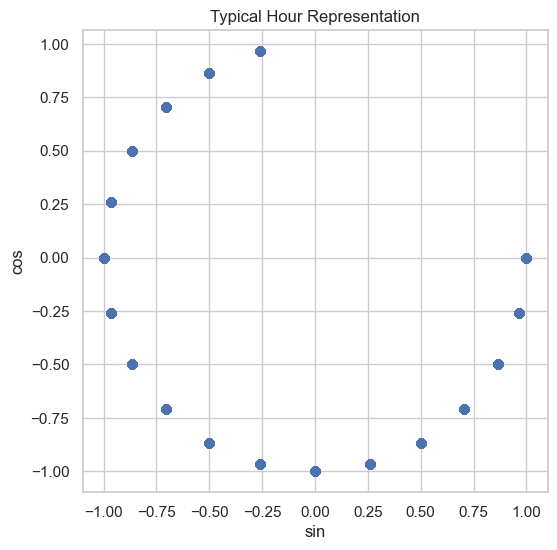

In [99]:
plt.figure(figsize=(6,6))
plt.scatter(ci_clean['typical_hour_sin'], ci_clean['typical_hour_cos'])
plt.title('Typical Hour Representation')
plt.xlabel('sin')
plt.ylabel('cos')
plt.grid(True)
plt.show()

<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">


Time-of-day data is inherently cyclical (23:00 is closer to 01:00 than it is to 13:00). To ensure our model understands this relationship, we map the linear `typical_hour` onto a 2D coordinate system.

* **Objective:** Transform the 24-hour cycle into Sine and Cosine components using a `cyclic_transformation`.
* **The Logic:** Raw numerical hours (0-23) create a "jump" or distance gap between the end of one day and the start of the next.
    * By mapping hours to a circle, **Hour 23** and **Hour 0** become spatially adjacent, preserving the temporal continuity of human behavior.
* **Impact:** The resulting scatter plot forms a perfect circle, confirming that the "Typical Hour" has been successfully projected into a format that allows clustering algorithms to calculate meaningful distances between different times of day.

</div>

In [100]:
print("Updated data types:")
display(ci_clean.dtypes)

Updated data types:


customer_id                                         int64
customer_name                                      object
customer_gender                                    object
customer_birthdate                         datetime64[ns]
kids_home                                         float64
teens_home                                        float64
number_complaints                                 float64
distinct_stores_visited                           float64
lifetime_spend_groceries                          float64
lifetime_spend_electronics                        float64
typical_hour                                      float64
lifetime_spend_vegetables                         float64
lifetime_spend_nonalcohol_drinks                  float64
lifetime_spend_alcohol_drinks                     float64
lifetime_spend_meat                               float64
lifetime_spend_fish                               float64
lifetime_spend_hygiene                            float64
lifetime_spend

In [101]:
# Separate feature groups for preprocessing

binary_features = [
    col for col in ci_clean.columns
    if ci_clean[col].nunique() == 2
]

print("Binary features:")
display(binary_features)

Binary features:


['customer_gender']

<a id="section-2-5-missing-values-treatment"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>2.5 Missing Values Treatment</b></h3>
</div>


In [102]:
print("Missing values BEFORE imputation:")
display(ci_clean.isna().sum())

Missing values BEFORE imputation:


customer_id                                    0
customer_name                                  0
customer_gender                                0
customer_birthdate                           159
kids_home                                    323
teens_home                                   324
number_complaints                            636
distinct_stores_visited                      315
lifetime_spend_groceries                       0
lifetime_spend_electronics                   633
typical_hour                                 638
lifetime_spend_vegetables                    639
lifetime_spend_nonalcohol_drinks               0
lifetime_spend_alcohol_drinks                318
lifetime_spend_meat                          645
lifetime_spend_fish                          965
lifetime_spend_hygiene                       323
lifetime_spend_videogames                    644
lifetime_spend_petfood                       641
lifetime_total_distinct_products               0
percentage_of_produc

In [103]:
zero_cols = ['kids_home', 'teens_home', 'number_complaints']

for col in zero_cols:
    if col in ci_clean.columns:
        ci_clean[col] = ci_clean[col].fillna(0)

In [104]:
ci_clean.rename(columns={'loyalty_card_number': 'customer_loyalty_flag'}, inplace=True)

ci_clean['customer_loyalty_flag'] = ci_clean['customer_loyalty_flag'].fillna(0).apply(lambda x: 1 if x != 0 else 0)

print(ci_clean['customer_loyalty_flag'].value_counts())

customer_loyalty_flag
1    19359
0    12688
Name: count, dtype: int64


<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">


Handling null values is a critical step to prevent model bias and calculation errors. In this section, we address the sparsity discovered in several key features.

* **Objective:** Quantify missing data using `.isna().sum()` and apply domain-specific imputation rules.
* **Treatment Logic:**
    * **Zero Imputation:** For count-based features like `kids_home`, `teens_home`, and `number_complaints`, missing values are treated as **0**, assuming the absence of a record implies a zero count.
    * **Flag Transformation:** The `loyalty_card_number` column is renamed to `customer_loyalty_flag` and converted into a binary indicator ($1$ for members, $0$ for non-members).
* **Impact:** By resolving the 13,106 missing loyalty entries and filling behavioral counts, we ensure the dataset is structurally complete. This prepares the "sparse" features for statistical analysis without losing significant row volume.

</div>

In [105]:
print(f"Shape before removing semi-constants: {ci_clean.shape}")

protected_cols = [
    'customer_id',
    'loyalty_card_number',
    'customer_loyalty_flag',
    'is_male',
    'education_level'
]

ci_clean = utils.remove_semi_constant_features(
    ci_clean,
    threshold=0.99,
    exclude_cols=protected_cols
)

print(f"Shape after removing semi-constants: {ci_clean.shape}")


Shape before removing semi-constants: (32047, 27)
Semi-constant columns removed (>=99% identical): []
Shape after removing semi-constants: (32047, 27)


<a id="section-3-aggregation-feature-engineering"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>3. Aggregation Feature Engineering</b></h3>
</div>


In [106]:
today = pd.Timestamp.now().normalize()
ci_clean['customer_age'] = (today - ci_clean['customer_birthdate']).dt.days // 365

invalid_age = (
    (ci_clean['customer_age'] < 16) |
    (ci_clean['customer_age'] > 100)
)

print(f"Minimum Age: {ci_clean['customer_age'].min()}")
print(f"Maximum Age: {ci_clean['customer_age'].max()}")
print(f"Invalid or suspicious ages: {invalid_age.sum()}")

ci_clean.loc[invalid_age, 'customer_age'] = np.nan
ci_clean.drop(columns=['customer_birthdate'], inplace=True)


Minimum Age: 24.0
Maximum Age: 86.0
Invalid or suspicious ages: 0


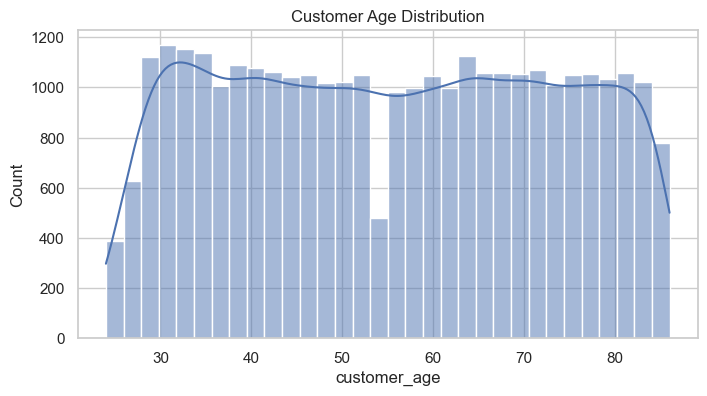

In [107]:
plt.figure(figsize=(8,4))

sns.histplot(
    ci_clean["customer_age"],
    kde=True
)

plt.title("Customer Age Distribution")

plt.show()

In [108]:
# Safely extract education level and clean customer name using regex-based logic
education_df = ci_clean.apply(utils.get_education_info, axis=1)

ci_clean["education_level"] = education_df[0].astype(int)
ci_clean["clean_customer_name"] = education_df[1]

print("Distribution of identified education levels:")
print(ci_clean["education_level"].value_counts().sort_index())

display(ci_clean[["customer_name", "clean_customer_name", "education_level"]].head())

Distribution of identified education levels:
education_level
0    17215
1     4987
2     4908
3     4937
Name: count, dtype: int64


,customer_name,clean_customer_name,education_level
0,Bsc. Crystal Kitchens,Crystal Kitchens,1
1,Bsc. Glenda Bauman,Glenda Bauman,1
2,Msc. Antonio Campbell,Antonio Campbell,2
3,John Kelling,John Kelling,0
4,Arthur Dematteo,Arthur Dematteo,0


In [109]:
ci_clean['is_male'] = ci_clean['customer_gender'].map({'male': 1, 'female': 0})
display(ci_clean[['customer_gender', 'is_male']].head())

,customer_gender,is_male
0,female,0
1,female,0
2,male,1
3,male,1
4,male,1


In [110]:
ci_clean.drop(columns=['customer_gender'], inplace=True)

<div style="background-color:#F9FCFF; padding:20px; border-radius:10px;">

This step turns raw demographic information into machine-learning-friendly variables.

* <b>Education level:</b> extracted safely from <code>customer_name</code> using regex, so customer names are not accidentally corrupted.
* <b>Gender:</b> encoded as a binary flag, making it compatible with distance-based models.
* <b>Customer age:</b> calculated from birthdate and checked for unrealistic values before imputation.

The result is a cleaner dataset with less text noise and more useful numerical signal.

</div>


In [111]:
ci_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,32047.0,19986.821543,11531.071417,3.000000,10001.500000,1.998300e+04,29957.500000,40000.000000
kids_home,32047.0,1.111368,1.146368,0.000000,0.000000,1.000000e+00,1.000000,8.000000
teens_home,32047.0,0.892689,0.960233,0.000000,0.000000,1.000000e+00,1.000000,6.000000
number_complaints,32047.0,0.920897,0.895398,0.000000,0.000000,1.000000e+00,1.000000,7.000000
distinct_stores_visited,31732.0,3.173074,1.676205,1.000000,2.000000,3.000000e+00,4.000000,10.000000
lifetime_spend_groceries,32047.0,16288.392330,11960.629475,0.000000,8638.000000,1.301600e+04,20803.500000,104670.000000
lifetime_spend_electronics,31414.0,2763.375406,3458.772641,0.000000,576.000000,1.466000e+03,3740.750000,35299.000000
typical_hour,31409.0,12.609889,4.823776,6.000000,8.000000,1.200000e+01,16.000000,23.000000
lifetime_spend_vegetables,31408.0,729.594530,653.481445,0.000000,228.000000,4.740000e+02,1077.000000,3282.000000
lifetime_spend_nonalcohol_drinks,32047.0,464.318407,275.320988,0.000000,241.000000,4.220000e+02,640.000000,2180.000000


In [112]:
ci_clean.columns

Index(['customer_id', 'customer_name', 'kids_home', 'teens_home',
       'number_complaints', 'distinct_stores_visited',
       'lifetime_spend_groceries', 'lifetime_spend_electronics',
       'typical_hour', 'lifetime_spend_vegetables',
       'lifetime_spend_nonalcohol_drinks', 'lifetime_spend_alcohol_drinks',
       'lifetime_spend_meat', 'lifetime_spend_fish', 'lifetime_spend_hygiene',
       'lifetime_spend_videogames', 'lifetime_spend_petfood',
       'lifetime_total_distinct_products',
       'percentage_of_products_bought_promotion', 'year_first_transaction',
       'customer_loyalty_flag', 'latitude', 'longitude', 'typical_hour_sin',
       'typical_hour_cos', 'customer_age', 'education_level',
       'clean_customer_name', 'is_male'],
      dtype='object')

<a id="section-4-missing-values-imputation"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>4. KNN Missing Values Imputation</b></h3>
</div>


In [113]:
# Remove raw text columns after extracting the useful information
ci_clean.drop(columns=["customer_name", "clean_customer_name"], inplace=True, errors="ignore")

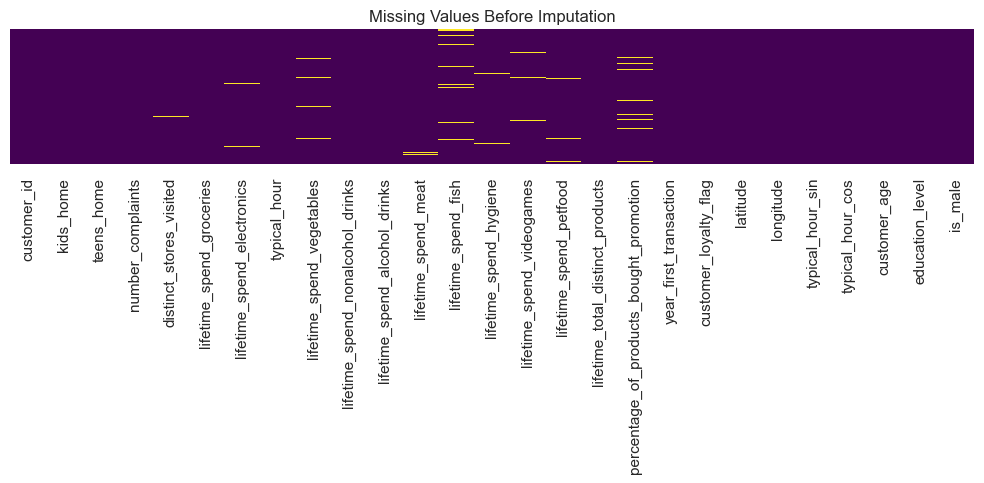

,Missing Count,Percentage (%)
percentage_of_products_bought_promotion,1990,6.21
lifetime_spend_fish,965,3.01
lifetime_spend_meat,645,2.01
lifetime_spend_videogames,644,2.01
lifetime_spend_petfood,641,2.00
typical_hour,638,1.99
typical_hour_cos,638,1.99
typical_hour_sin,638,1.99
lifetime_spend_vegetables,639,1.99
lifetime_spend_electronics,633,1.98


Imputation validation issues found:
  - longitude max increased from -9.04 to -9.04
  - typical_hour_sin has negative values after imputation: -1.00
  - typical_hour_cos has negative values after imputation: -1.00
Remaining missing values: 0


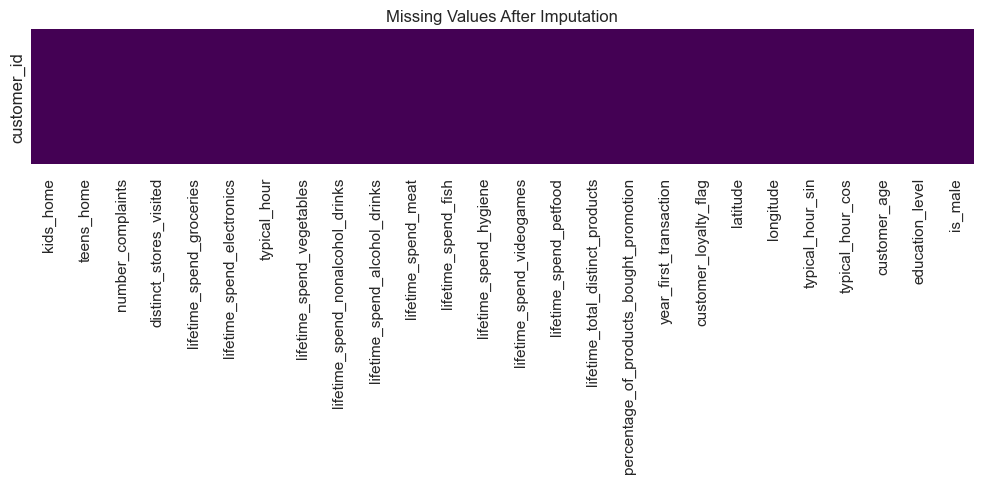

In [114]:
utils.plot_missing_heatmap(ci_clean, "Missing Values Before Imputation")
display(utils.get_missing_report(ci_clean))

# Keep customer_id protected from KNN distances by using it as the DataFrame index.
# This prevents the imputer from treating close customer IDs as geometrically similar clients.
if "customer_id" in ci_clean.columns:
    ci_clean = ci_clean.set_index("customer_id", drop=True)

ci_before_imputation = ci_clean.copy()

# Exclude already-clean binary/categorical flags from KNN distance calculations.
imputation_exclude_cols = [
    "customer_loyalty_flag",
    "is_male",
    "education_level",
]
imputation_exclude_cols = [col for col in imputation_exclude_cols if col in ci_clean.columns]

ci_clean = utils.apply_knn_imputation(
    ci_clean,
    n_neighbors=5,
    exclude_cols=imputation_exclude_cols,
)

imputed_columns = [
    col for col in ci_clean.select_dtypes(include=[np.number]).columns
    if col not in imputation_exclude_cols
]

imputation_valid = utils.validate_imputation(
    df_original=ci_before_imputation,
    df_imputed=ci_clean,
    columns=imputed_columns,
)

if imputation_valid:
    print("Success: Imputation validated and integrated without detected anomalies.")

print("Remaining missing values:", ci_clean.isnull().sum().sum())
utils.plot_missing_heatmap(ci_clean, "Missing Values After Imputation")

In [115]:
to_int = [
    'kids_home',
    'teens_home',
    'number_complaints',
    'distinct_stores_visited',
    'lifetime_total_distinct_products',
    'year_first_transaction',
    'customer_loyalty_flag',
    'education_level',
    'is_male'
]

for col in to_int:
    if col in ci_clean.columns:
        ci_clean[col] = ci_clean[col].round().astype('Int64')

In [116]:
ci_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32047 entries, 3 to 40000
Data columns (total 26 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   kids_home                                32047 non-null  Int64  
 1   teens_home                               32047 non-null  Int64  
 2   number_complaints                        32047 non-null  Int64  
 3   distinct_stores_visited                  32047 non-null  Int64  
 4   lifetime_spend_groceries                 32047 non-null  float64
 5   lifetime_spend_electronics               32047 non-null  float64
 6   typical_hour                             32047 non-null  float64
 7   lifetime_spend_vegetables                32047 non-null  float64
 8   lifetime_spend_nonalcohol_drinks         32047 non-null  float64
 9   lifetime_spend_alcohol_drinks            32047 non-null  float64
 10  lifetime_spend_meat                      32047 non-

<a id="section-5-transformation-feature-engineering"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>5. Transformation Feature Engineering</b></h3>
</div>


In [117]:
# A. Create Tenure (Years as a customer)
ci_clean['tenure'] = current_year - ci_clean['year_first_transaction']

# B. Household Dynamics: Total Children
ci_clean['total_children'] = ci_clean['kids_home'] + ci_clean['teens_home']

# C. Create a technology spend
ci_clean["lifetime_spend_technology"] = (
    ci_clean["lifetime_spend_electronics"] +
    ci_clean["lifetime_spend_videogames"]
)

ci_clean.drop(
    columns=["lifetime_spend_electronics", "lifetime_spend_videogames"],
    inplace=True
)

In [118]:
ci_clean.columns

Index(['kids_home', 'teens_home', 'number_complaints',
       'distinct_stores_visited', 'lifetime_spend_groceries', 'typical_hour',
       'lifetime_spend_vegetables', 'lifetime_spend_nonalcohol_drinks',
       'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat',
       'lifetime_spend_fish', 'lifetime_spend_hygiene',
       'lifetime_spend_petfood', 'lifetime_total_distinct_products',
       'percentage_of_products_bought_promotion', 'year_first_transaction',
       'customer_loyalty_flag', 'latitude', 'longitude', 'typical_hour_sin',
       'typical_hour_cos', 'customer_age', 'education_level', 'is_male',
       'tenure', 'total_children', 'lifetime_spend_technology'],
      dtype='object')

<div style="background-color:#F9FCFF; padding:20px; border-radius:10px;">

Here we create higher-level customer features from more granular columns. This makes the dataset easier for clustering algorithms to interpret.

* <b>Tenure:</b> years since the first transaction.
* <b>Total children:</b> combination of kids and teenagers at home.
* <b>Technology spend:</b> combination of electronics and videogame spend.
* <b>Spend ratios:</b> later converted into percentage-based behavior features.

These engineered features help describe customers by behavior and lifecycle stage rather than by raw columns only.

</div>


### Total Spent and Percentage of products bought


In [119]:
# Spending columns
spend_cols = [
    'lifetime_spend_groceries',
    'lifetime_spend_vegetables',
    'lifetime_spend_nonalcohol_drinks',
    'lifetime_spend_alcohol_drinks',
    'lifetime_spend_meat',
    'lifetime_spend_fish',
    'lifetime_spend_hygiene',
    'lifetime_spend_petfood',
    'lifetime_spend_technology'
]

# Create total spending variable
ci_clean['total_spend'] = ci_clean[spend_cols].sum(axis=1)

# Create percentage spending variables
for col in spend_cols:

    pct_col_name = col.replace(
        'lifetime_spend_',
        'pct_spend_'
    )

    ci_clean[pct_col_name] = np.where(
        ci_clean['total_spend'] > 0,
        ci_clean[col] / ci_clean['total_spend'],
        0
    )

# Check created variables
display(
    ci_clean[
        ['total_spend'] +
        [col for col in ci_clean.columns if col.startswith('pct_spend_')]
    ].head()
)

,total_spend,pct_spend_groceries,pct_spend_vegetables,pct_spend_nonalcohol_drinks,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology
customer_id,,,,,,,,,,
3,18590.0,0.631038,0.020065,0.017375,0.009521,0.001506,0.011458,0.029693,0.020656,0.258687
4,20233.0,0.676815,0.099442,0.026343,0.004695,0.002125,0.000741,0.092918,0.032867,0.064054
5,15549.0,0.797929,0.035694,0.006496,0.007589,0.081356,0.017557,0.032607,0.014277,0.006496
7,14952.0,0.501137,0.005618,0.050629,0.075776,0.065008,0.072432,0.032437,0.012306,0.184658
8,25797.0,0.356127,0.014730,0.022948,0.027833,0.041400,0.039346,0.011513,0.017095,0.469008


In [120]:
# Apply log transform ONLY to total_spend
ci_clean['log_total_spend'] = np.log1p(
    np.clip(ci_clean['total_spend'], 0, None)
)

print("Created column: log_total_spend")

display(
    ci_clean[['total_spend', 'log_total_spend']].head()
)

Created column: log_total_spend


,total_spend,log_total_spend
customer_id,,
3,18590.0,9.830433
4,20233.0,9.915120
5,15549.0,9.651816
7,14952.0,9.612667
8,25797.0,10.158052


In [121]:
# Remove redundant spending variables
cols_to_drop = [
    'lifetime_spend_groceries',
    'lifetime_spend_vegetables',
    'lifetime_spend_nonalcohol_drinks',
    'lifetime_spend_alcohol_drinks',
    'lifetime_spend_meat',
    'lifetime_spend_fish',
    'lifetime_spend_hygiene',
    'lifetime_spend_petfood',
    'lifetime_spend_technology',
    'total_spend'
]

ci_clean = ci_clean.drop(columns=cols_to_drop)

print("Remaining columns:")
display(ci_clean.columns.tolist())

Remaining columns:


['kids_home',
 'teens_home',
 'number_complaints',
 'distinct_stores_visited',
 'typical_hour',
 'lifetime_total_distinct_products',
 'percentage_of_products_bought_promotion',
 'year_first_transaction',
 'customer_loyalty_flag',
 'latitude',
 'longitude',
 'typical_hour_sin',
 'typical_hour_cos',
 'customer_age',
 'education_level',
 'is_male',
 'tenure',
 'total_children',
 'pct_spend_groceries',
 'pct_spend_vegetables',
 'pct_spend_nonalcohol_drinks',
 'pct_spend_alcohol_drinks',
 'pct_spend_meat',
 'pct_spend_fish',
 'pct_spend_hygiene',
 'pct_spend_petfood',
 'pct_spend_technology',
 'log_total_spend']

<a id="section-6-outliers-treatment"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>6. Outliers Treatment</b></h3>
</div>


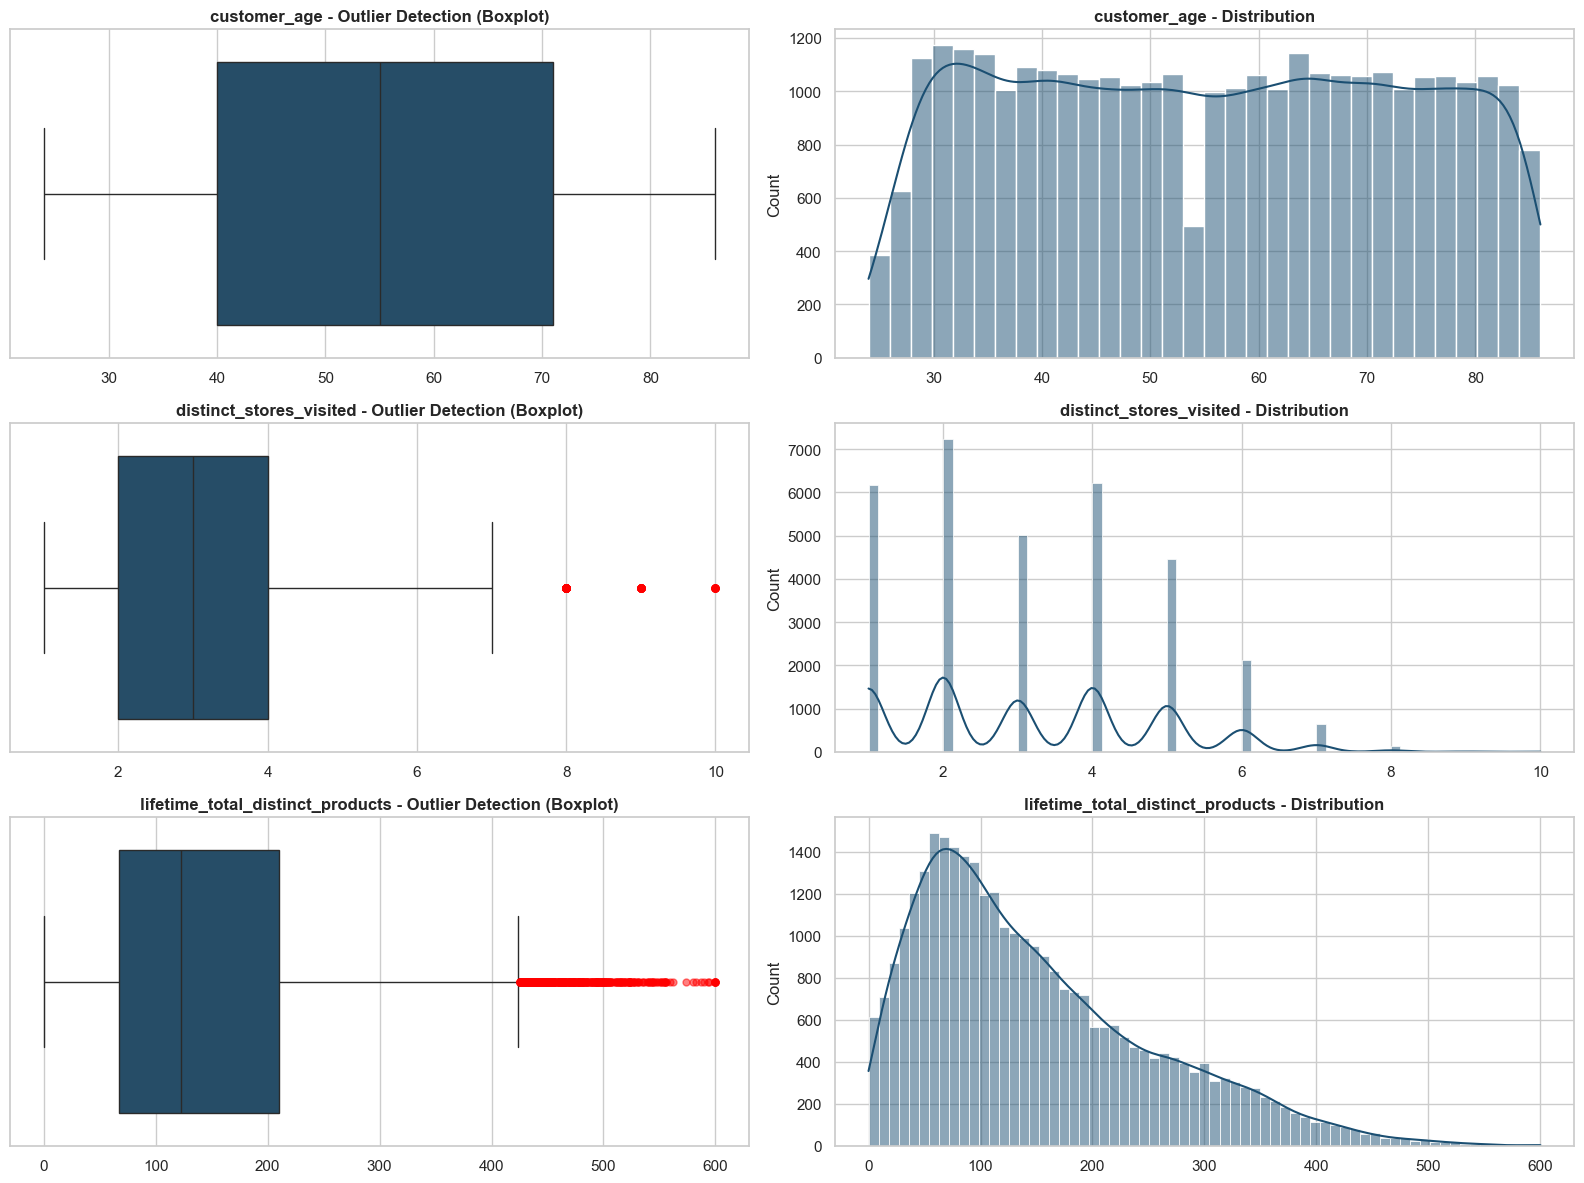

In [122]:
# Columns to inspect before outlier treatment
spend_cols = [col for col in ci_clean.columns if col.startswith('lifetime_spend_')]
other_numeric = [
    'customer_age',
    'distinct_stores_visited',
    'lifetime_total_distinct_products'
]
cols_to_visualize = [col for col in spend_cols + other_numeric if col in ci_clean.columns]

CUSTOM_BLUE = "#1B4F72"
sns.set_theme(style="whitegrid")

n_features = len(cols_to_visualize)

if n_features == 0:
    print("No columns available for outlier visualization.")
else:
    fig, axes = plt.subplots(nrows=n_features, ncols=2, figsize=(16, n_features * 4))

    if n_features == 1:
        axes = np.array([axes])

    for i, col in enumerate(cols_to_visualize):
        sns.boxplot(
            x=ci_clean[col],
            ax=axes[i, 0],
            color=CUSTOM_BLUE,
            flierprops={
                "marker": "o",
                "markerfacecolor": "red",
                "markeredgecolor": "red",
                "markersize": 5,
                "alpha": 0.5,
            },
        )
        axes[i, 0].set_title(f'{col} - Outlier Detection (Boxplot)', fontsize=12, fontweight='bold')
        axes[i, 0].set_xlabel('')

        sns.histplot(ci_clean[col], kde=True, ax=axes[i, 1], color=CUSTOM_BLUE)
        axes[i, 1].set_title(f'{col} - Distribution', fontsize=12, fontweight='bold')
        axes[i, 1].set_xlabel('')

    plt.tight_layout()
    plt.show()


In [123]:
spend_cols = [
    col for col in ci_clean.columns
    if 'spend' in col.lower() and 'pct' not in col.lower() and col != 'total_spend'
]

print("Spend columns used:", spend_cols)

other_numeric = [
    'customer_age',
    'distinct_stores_visited',
    'lifetime_total_distinct_products'
]

cols_to_treat = spend_cols + other_numeric
cols_to_treat = [col for col in cols_to_treat if col in ci_clean.columns]

print(cols_to_treat)

Spend columns used: ['log_total_spend']
['log_total_spend', 'customer_age', 'distinct_stores_visited', 'lifetime_total_distinct_products']


In [124]:
ci_clean = utils.handle_extreme_outliers(ci_clean, cols_to_treat, strategy='cap')

print(f"Extreme outliers treated in {len(cols_to_treat)} columns.")

Extreme outliers treated in 4 columns.


<a id="section-7-multivariate-analysis"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>7. Multivariate Analysis: Feature Correlation</b></h3>
</div>


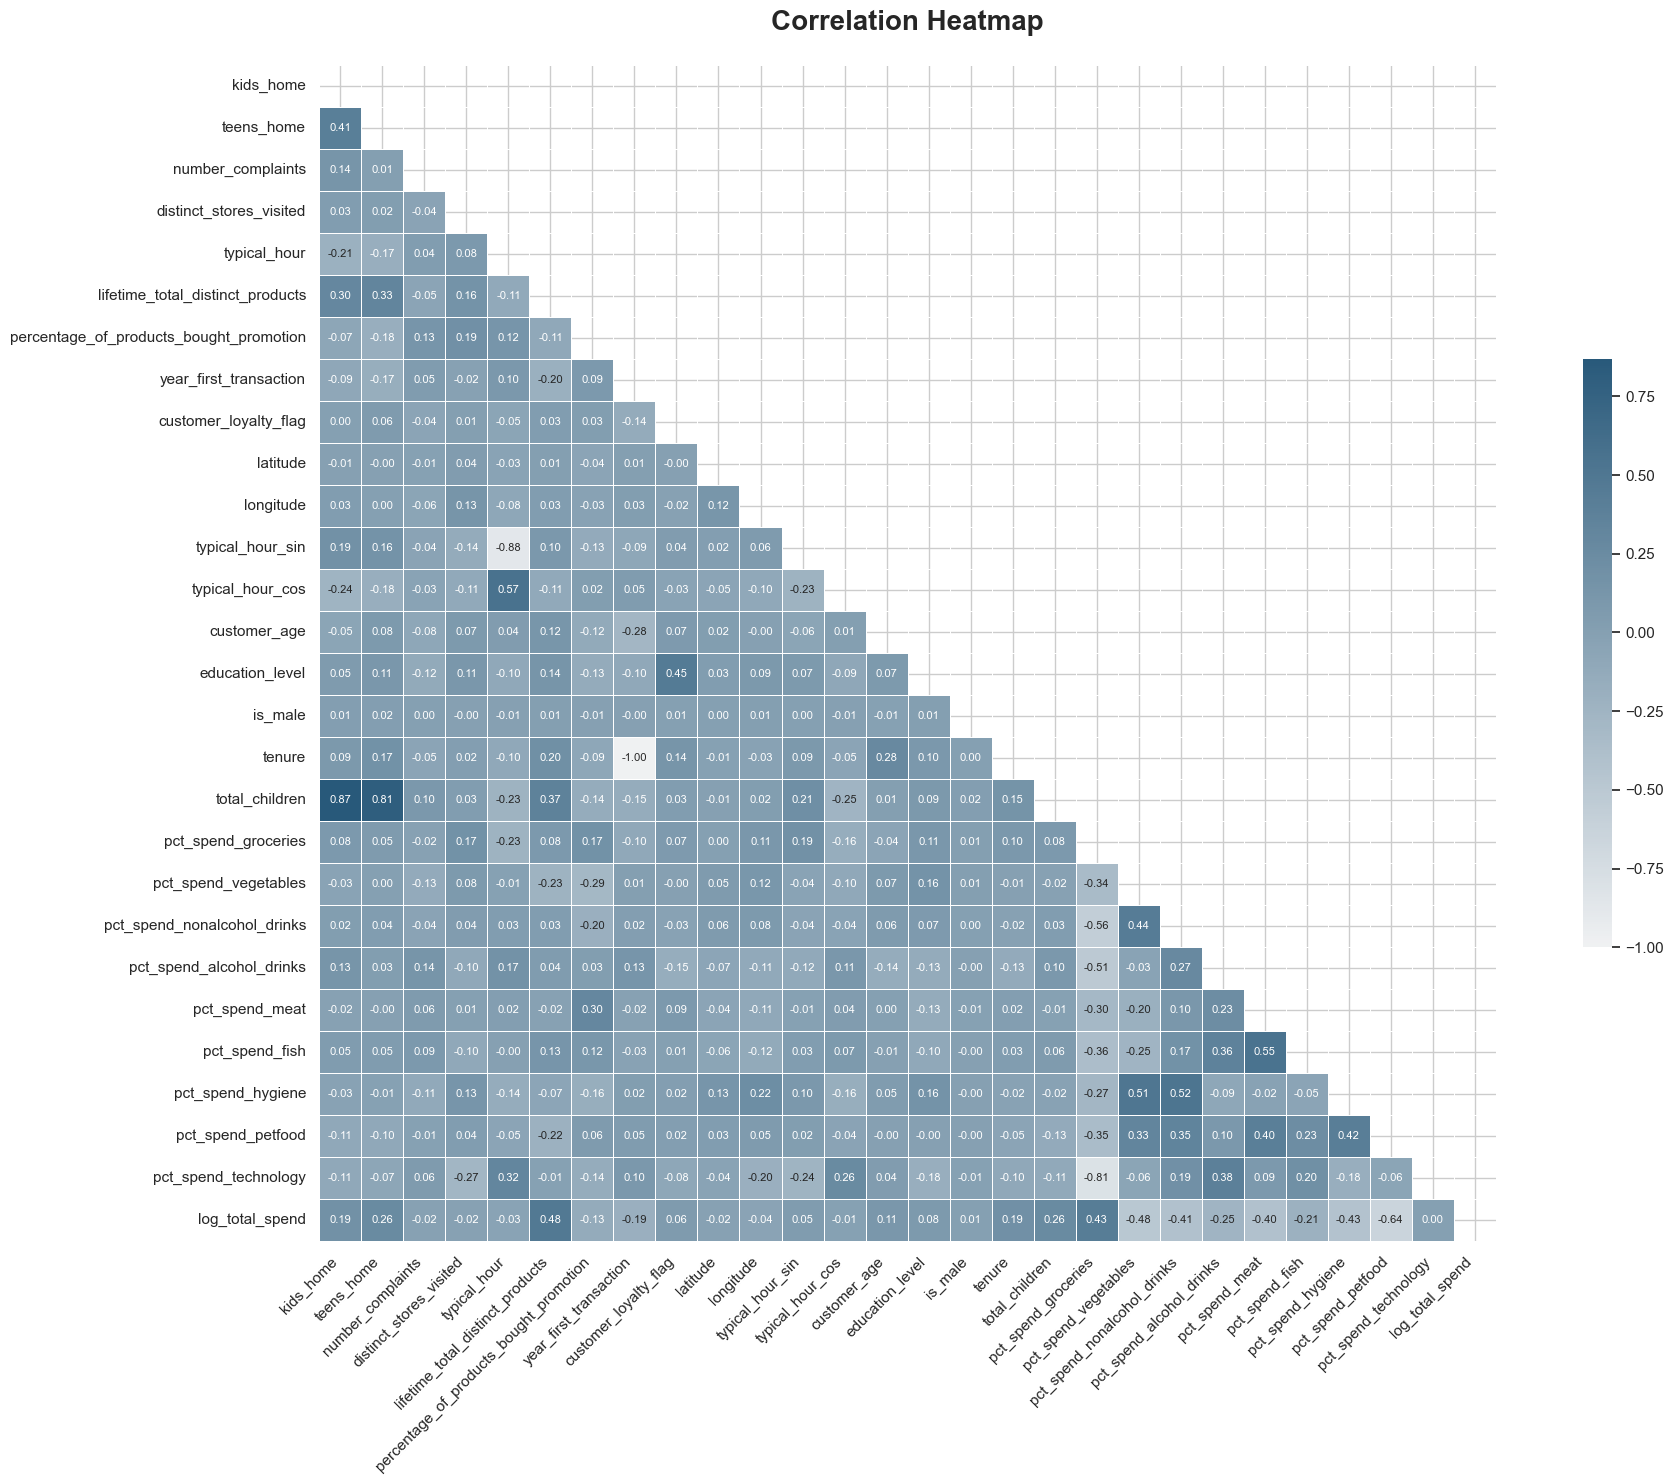

In [125]:
# Select only relevant columns (excluding IDs) for a cleaner map
cols_to_corr = ci_clean.select_dtypes(include=np.number).columns.tolist()
if 'loyalty_card_number' in cols_to_corr: cols_to_corr.remove('loyalty_card_number')

# Call the function from utils
utils.cor_heatmap(ci_clean[cols_to_corr].corr())

In [126]:
high_corrs = utils.get_high_correlations(ci_clean, threshold=0.7)

display(high_corrs)

,Variable 1,Variable 2,Correlation
3,tenure,year_first_transaction,1.000000
2,typical_hour_sin,typical_hour,0.878515
0,total_children,kids_home,0.868407
1,total_children,teens_home,0.805960
4,pct_spend_technology,pct_spend_groceries,0.805835


<div style="background-color:#F9FCFF; padding:20px; border-radius:10px;">

At this stage, we check how strongly the numerical variables are related to one another. This is important because highly redundant features can distort distance-based clustering.

* <b>Perfect or near-perfect correlations</b> are candidates for removal.
* <b>Aggregated variables</b> are preferred when they represent the same information more clearly.
* <b>Correlation review</b> supports a cleaner and more defensible feature-selection step.

</div>


In [127]:
ci_clean

,kids_home,teens_home,number_complaints,distinct_stores_visited,typical_hour,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,customer_loyalty_flag,latitude,longitude,typical_hour_sin,typical_hour_cos,customer_age,education_level,is_male,tenure,total_children,pct_spend_groceries,pct_spend_vegetables,pct_spend_nonalcohol_drinks,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology,log_total_spend
customer_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3,1,1,1,3.0,13.4,189.0,0.631599,2020,1,38.794428,-9.215739,0.010342,-2.649291e-01,56.0,1,0,6,2,0.631038,0.020065,0.017375,0.009521,0.001506,0.011458,0.029693,0.020656,0.258687,9.830433
4,1,0,0,2.0,13.0,130.0,0.149890,2013,1,38.751711,-9.179611,-0.148236,-7.395953e-01,50.0,1,0,13,1,0.676815,0.099442,0.026343,0.004695,0.002125,0.000741,0.092918,0.032867,0.064054,9.915120
5,0,0,0,2.0,11.0,81.0,0.069126,2005,0,38.780678,-9.160656,0.258819,-9.659258e-01,54.0,2,1,21,0,0.797929,0.035694,0.006496,0.007589,0.081356,0.017557,0.032607,0.014277,0.006496,9.651816
7,0,0,2,1.0,18.0,92.0,0.253609,2021,1,38.739548,-9.148679,-1.000000,-2.220446e-16,43.0,0,1,5,0,0.501137,0.005618,0.050629,0.075776,0.065008,0.072432,0.032437,0.012306,0.184658,9.612667
8,0,0,3,1.0,17.0,6.0,0.186569,2021,1,38.733071,-9.188188,-0.965926,-2.588190e-01,56.0,0,1,5,0,0.356127,0.014730,0.022948,0.027833,0.041400,0.039346,0.011513,0.017095,0.469008,10.158052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39996,0,0,2,1.0,12.4,162.0,0.261352,2014,0,38.742306,-9.163971,-0.100000,-5.732051e-01,53.0,0,1,12,0,0.023845,0.009538,0.028765,0.049900,0.051205,0.057932,0.003112,0.018373,0.757329,9.899530
39997,1,0,1,1.0,21.0,97.0,0.143479,2014,0,38.748505,-9.193445,-0.707107,7.071068e-01,71.0,0,1,12,1,0.285569,0.009858,0.016836,0.048001,0.044817,0.020393,0.007453,0.007690,0.559383,10.292857
39998,1,1,0,4.0,14.0,206.0,0.181917,2012,0,38.776003,-9.137943,-0.500000,-8.660254e-01,81.0,0,0,14,2,0.566980,0.112986,0.034885,0.008262,0.021679,0.004802,0.121390,0.018219,0.110797,9.558318


<a id="section-8-feature-selection-and-export"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>8. Feature Selection and Final Export</b></h3>
</div>


<div style="background-color:#F9FCFF; padding:20px; border-radius:10px;">

## Final clustering dataset

This step builds the scaled dataset that will be used in the clustering notebook.

The goal is simple: keep only numerical modeling features, remove columns that should not influence distance-based clustering, keep binary indicators unchanged, and store the scaled result in `info_clustering_scaled`.

</div>

In [128]:
# Build the final scaled dataset for clustering.
# This cell must be run before the export cell.

clustering_input = ci_clean.select_dtypes(include=[np.number]).copy()

# Remove columns that should not drive distance-based clustering.
columns_to_drop = [
    "loyalty_card_number",
    "birth_year",
    "year_first_transaction",
    "kids_home",
    "teens_home",
    "typical_hour",
]
clustering_input = clustering_input.drop(columns=columns_to_drop, errors="ignore")

# Keep binary features unscaled when they exist.
binary_features = [
    "customer_loyalty_flag",
    "is_male",
    "education_level",
]
binary_features = [col for col in binary_features if col in clustering_input.columns]

best_scaler, best_score, info_clustering_scaled = utils.test_scalers_kmeans(
    clustering_input,
    binary_cols=binary_features,
    k=4,
    random_state=42,
)

print(f"Final scaled dataset created with the {best_scaler} scaler.")
print(f"Silhouette score with k=4: {best_score:.4f}")
print(f"Scaled dataset shape: {info_clustering_scaled.shape}")
info_clustering_scaled.head()

Standard Scaler - Silhouette Score: 0.1267
MinMax Scaler - Silhouette Score: 0.1353
Robust Scaler - Silhouette Score: 0.2193

Best Scaler: Robust (Silhouette Score: 0.2193)
Final scaled dataset created with the Robust scaler.
Silhouette score with k=4: 0.2193
Scaled dataset shape: (32047, 24)


,number_complaints,distinct_stores_visited,lifetime_total_distinct_products,percentage_of_products_bought_promotion,latitude,longitude,typical_hour_sin,typical_hour_cos,customer_age,tenure,total_children,pct_spend_groceries,pct_spend_vegetables,pct_spend_nonalcohol_drinks,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology,log_total_spend,customer_loyalty_flag,is_male,education_level
customer_id,,,,,,,,,,,,,,,,,,,,,,,,
3,0.0,0.0,0.461538,1.049243,1.455070,-1.721835,0.007571,0.387135,0.032258,-0.833333,0.0,-0.327366,-0.036736,-0.090940,-0.428387,-0.939982,-0.422289,-0.036330,0.388199,1.474706,-0.129218,1,0,1
4,-1.0,-0.5,0.048951,-0.311199,0.107128,-0.668808,-0.108516,-0.394586,-0.161290,0.333333,-1.0,-0.109197,1.631791,0.450391,-0.588546,-0.920384,-0.798877,1.676601,1.240944,-0.205284,-0.008434,1,0,1
5,-1.0,-0.5,-0.293706,-0.539294,1.021173,-0.116301,0.189469,-0.767327,-0.032258,1.666667,-2.0,0.468022,0.291791,-0.747631,-0.492515,1.587951,-0.207940,0.042597,-0.057266,-0.702100,-0.383969,0,1,2
7,1.0,-1.0,-0.216783,-0.018275,-0.276669,0.232794,-0.732051,0.823443,-0.387097,-1.000000,-2.0,-0.946465,-0.340408,1.916300,1.770413,1.070404,1.720415,0.038006,-0.194939,0.835713,-0.439805,1,1,0
8,2.0,-1.0,-0.818182,-0.207611,-0.481052,-0.918785,-0.707107,0.397198,0.032258,-1.000000,-2.0,-1.637572,-0.148862,0.245482,0.179318,0.323009,0.557727,-0.528892,0.139499,3.290097,0.338048,1,1,0


<div style="background-color:#F9FCFF; padding:20px; border-radius:10px;">

## Export final files

The final cell only saves the prepared datasets. It does not recreate variables automatically, so the workflow stays clear and predictable when the notebook is run from top to bottom.

</div>

In [129]:
import os

parent_dir = os.path.dirname(os.getcwd())
output_dir = os.path.join(parent_dir, "datasets")
os.makedirs(output_dir, exist_ok=True)

# Export the main clustering dataset.
# customer_id is preserved in the index, so index=True keeps it in the CSV.
info_clustering_scaled.to_csv(
    os.path.join(output_dir, "info_clustering_ready.csv"),
    index=True,
)

# Export the isolated outliers dataset using the correct variable name.
if "outlier_dataset" in locals():
    outlier_dataset.to_csv(
        os.path.join(output_dir, "outlier_dataset.csv"),
        index=True,
    )
    print(f"Success: both files were saved in: {output_dir}")
else:
    print(f"Success: file 'info_clustering_ready.csv' was exported to: {output_dir}")

Success: file 'info_clustering_ready.csv' was exported to: c:\Users\pedro\Documents\projetos git\mlii26\CostumerSegP_MLII\datasets


<div style="background-color:#F9FCFF; padding:20px; border-radius:10px;">

The final clustering dataset is exported as <code>info_clustering_ready.csv</code>. If the extreme-spender subset was created earlier, it is also exported as <code>outlier_dataset.csv</code>.

Both exports preserve the DataFrame index, which is important because <code>customer_id</code> was moved to the index to protect it from KNN imputation and scaling.

</div>
